# 16_RFE — Feature Selection 실험 노트북

**규칙**
- 설정 변경 → `config/rfe_config.py` 만 수정
- 파이프라인 수정 → `src/rfe_core.py` 만 수정
- 이 노트북은 **관찰/실험 전용**

---

## 워크플로우

```
1. rfe_config.py 수정  →  MODE / 그룹 / 컬럼 설정
2. Cell 2 실행 (import + reload)
3. Cell 3 실행 (파이프라인 실행)
4. 결과 관찰
```

## 빠른 설정 가이드

| 목적 | MODE | 설정 |
|------|------|------|
| 공백에서 그룹 추가 | `add` | `INCLUDE_GROUPS` |
| 공백에서 개별 컬럼 추가 | `add` | `INCLUDE_COLS` |
| 전체에서 그룹 제거 | `drop` | `EXCLUDE_GROUPS` |
| 전체에서 개별 컬럼 제거 | `drop` | `EXCLUDE_COLS` |

In [21]:
# ── Cell 1: 환경 설정 ──────────────────────────────────────────
import sys, os, importlib

# 프로젝트 루트를 sys.path에 추가 (어떤 디렉토리에서 실행해도 동작)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for path in [PROJECT_ROOT, os.path.join(PROJECT_ROOT, 'src'), os.path.join(PROJECT_ROOT, 'config')]:
    if path not in sys.path:
        sys.path.insert(0, path)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'sys.path (상위 3개): {sys.path[:3]}')

PROJECT_ROOT: c:\Workspace\06_ML_projdect\26_1_COIN
sys.path (상위 3개): ['c:\\Workspace\\06_ML_projdect\\26_1_COIN\\config', 'c:\\Workspace\\06_ML_projdect\\26_1_COIN\\src', 'c:\\Workspace\\06_ML_projdect\\26_1_COIN']


In [22]:
# ── Cell 2: import + config 핫 리로드 ─────────────────────────
# rfe_config.py 수정 후 이 셀만 재실행하면 바로 반영됨
import rfe_config as cfg
import rfe_core   as core

importlib.reload(cfg)
importlib.reload(core)

print('✅  config / core 로드 완료')
print(f'   MODE           = {cfg.MODE}')
print(f'   TRAIN_PATH     = {cfg.TRAIN_PATH}')
print(f'   TEST_PATH      = {cfg.TEST_PATH}')
print(f'   CV_N_SPLITS    = {cfg.CV_N_SPLITS}')

if cfg.MODE == 'add':
    print(f'   INCLUDE_GROUPS = {cfg.INCLUDE_GROUPS}')
    print(f'   INCLUDE_COLS   = {cfg.INCLUDE_COLS}')
else:
    print(f'   EXCLUDE_GROUPS = {cfg.EXCLUDE_GROUPS}')
    print(f'   EXCLUDE_COLS   = {cfg.EXCLUDE_COLS}')

✅  config / core 로드 완료
   MODE           = add
   TRAIN_PATH     = c:\Workspace\06_ML_projdect\26_1_COIN\data\rfe_sample_data\rfe_train.parquet
   TEST_PATH      = c:\Workspace\06_ML_projdect\26_1_COIN\data\rfe_sample_data\rfe_test.parquet
   CV_N_SPLITS    = 3
   INCLUDE_GROUPS = []
   INCLUDE_COLS   = ['s187_days_since_first', 'error_density_14d', 'smart_187_raw', 'smart_197_raw', 's187_28d_sum', 'total_seeks_28d_max', 'total_seeks_28d_asfd', 'cumulative_error_score', 's5_days_since_first', 'age_weighted_workload', 's242_14d_mean', 'smart_241_raw', 'smart_242_raw', 'smart_9_raw', 's241_14d_mean', 's241_diff', 's241_7d_max', 'total_seeks_14d_mean', 's190_28d_mean', 's190_28d_ewma', 's190_7d_ewma', 'total_reads_7d_max', 'total_reads_14d_max', 's194_14d_std', 's194_28d_mean', 'smart_184_raw', 'total_reads_28d_std', 'total_reads_7d_dai']


📂  데이터 로드 중...
  FEATURE AUDIT  │  MODE = ADD

✅  INCLUDE_COLS (개별 포함): ['s187_days_since_first', 'error_density_14d', 'smart_187_raw', 'smart_197_raw', 's187_28d_sum', 'total_seeks_28d_max', 'total_seeks_28d_asfd', 'cumulative_error_score', 's5_days_since_first', 'age_weighted_workload', 's242_14d_mean', 'smart_241_raw', 'smart_242_raw', 'smart_9_raw', 's241_14d_mean', 's241_diff', 's241_7d_max', 'total_seeks_14d_mean', 's190_28d_mean', 's190_28d_ewma', 's190_7d_ewma', 'total_reads_7d_max', 'total_reads_14d_max', 's194_14d_std', 's194_28d_mean', 'smart_184_raw', 'total_reads_28d_std', 'total_reads_7d_dai']

📊  데이터 내 전체 컬럼: 168
📊  그룹 JSON 내 정의된 컬럼: 307
⚠️   그룹 JSON에 있지만 데이터 없음: 139 cols

✅  최종 사용 feature 수: 28

🏋️  학습 시작  │  features=28, train=299,442, test=682,962
   pos rate: train=0.0909, test=0.0099

  Fold 1: PR-AUC = 0.74126
  Fold 2: PR-AUC = 0.74244
  Fold 3: PR-AUC = 0.73357

  전체 train 재학습 중 (test 평가용)...
  RESULT SUMMARY

  CV PR-AUC  : 0.73909  ±  0.00393
  CV scores  : [0.

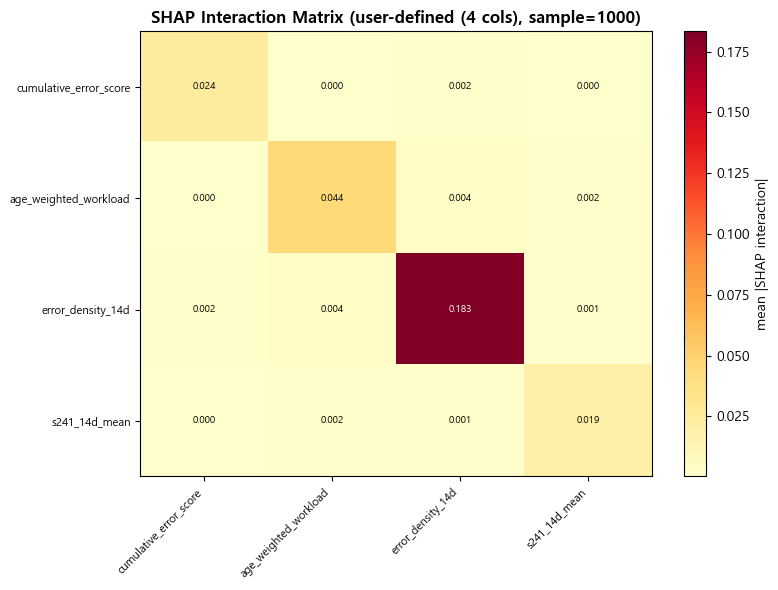


📊  혼동행렬 (테스트 세트) 출력 중...


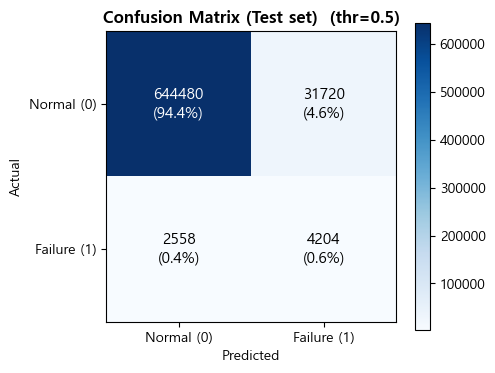


[Classification Report]
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    676200
     Failure       0.12      0.62      0.20      6762

    accuracy                           0.95    682962
   macro avg       0.56      0.79      0.59    682962
weighted avg       0.99      0.95      0.97    682962

  Precision (Failure) : 0.1170
  Recall    (Failure) : 0.6217
  Specificity         : 0.9531


In [ ]:
# ── Cell 3: 파이프라인 실행 ──────────────────────────────────
# show_gain=False 또는 show_shap=False 로 중요도 플롯 개별 ON/OFF 가능
result = core.run_pipeline(
    cfg,
    show_gain=False,
    show_shap=False,
    show_interaction=True,      # shap 상호작용값
    interaction_cols=[

'smart_197_raw',

'smart_184_raw', 's187_28d_sum'
    ],
    # interaction_top_n=10,       # 상위 몇 개 feature 간 상호작용 볼지
    interaction_sample_n=1000,   # 샘플 수 (많을수록 느림)
)

In [24]:
# ── Cell 4: 결과 확인 (선택) ─────────────────────────────────
print('\n[ Gain Top 10 ]')
display(result['df_gain'].head(10))

print('\n[ SHAP Top 10 ]')
display(result['df_shap'].head(10))

print('\n[ 최종 feature 목록 ]')
print(result['features'])


[ Gain Top 10 ]


,feature,gain
0,smart_197_raw,424106.197321
1,smart_187_raw,134023.908446
2,total_seeks_28d_asfd,54645.734186
3,smart_184_raw,42977.535036
4,smart_9_raw,42082.730199
5,smart_241_raw,37762.319246
6,smart_242_raw,33561.152252
7,error_density_14d,32550.127744
8,total_seeks_28d_max,27503.659707
9,s241_diff,22228.496193



[ SHAP Top 10 ]


,feature,mean_abs_shap
0,smart_197_raw,0.245690
1,smart_187_raw,0.223368
2,total_seeks_28d_asfd,0.191391
3,smart_9_raw,0.177069
4,error_density_14d,0.129198
5,smart_241_raw,0.117818
6,smart_242_raw,0.100351
7,s242_14d_mean,0.097895
8,total_seeks_14d_mean,0.088940
9,total_seeks_28d_max,0.057991



[ 최종 feature 목록 ]
['age_weighted_workload', 'cumulative_error_score', 'error_density_14d', 's187_28d_sum', 's187_days_since_first', 's190_28d_ewma', 's190_28d_mean', 's190_7d_ewma', 's194_14d_std', 's194_28d_mean', 's241_14d_mean', 's241_7d_max', 's241_diff', 's242_14d_mean', 's5_days_since_first', 'smart_184_raw', 'smart_187_raw', 'smart_197_raw', 'smart_241_raw', 'smart_242_raw', 'smart_9_raw', 'total_reads_14d_max', 'total_reads_28d_std', 'total_reads_7d_dai', 'total_reads_7d_max', 'total_seeks_14d_mean', 'total_seeks_28d_asfd', 'total_seeks_28d_max']


In [25]:
# ── Cell 5: feature audit 상세 (선택) ───────────────────────
# 어떤 feature가 왜 살아남고 왜 죽었는지 추적
audit = result['audit']

print(f"MODE: {audit['mode']}")
print(f"최종 feature 수: {audit['final_feature_count']}")

if audit['warnings']:
    print('\n⚠️  경고:')
    for w in audit['warnings']:
        print(f'  {w}')

if audit['mode'] == 'drop' and audit['excluded_groups']:
    print('\n🗑️  제외된 그룹 상세:')
    for g, info in audit['excluded_groups'].items():
        print(f'  [{g}]')
        print(f'    제거됨: {info["removed"][:5]}{"..." if len(info["removed"])>5 else ""}')
        if info['not_in_data']:
            print(f'    데이터에 없음: {info["not_in_data"]}')

if audit['missing_in_data']:
    print(f'\n⚠️  JSON에 정의됐지만 데이터에 없는 컬럼 ({len(audit["missing_in_data"])}개):')
    print(audit['missing_in_data'])

MODE: add
최종 feature 수: 28

⚠️  JSON에 정의됐지만 데이터에 없는 컬럼 (139개):
['error_saturation_score', 'is_warmup_7d', 'log_shock_fly_interaction', 's183_14d_sum', 's183_28d_sum', 's184_14d_sum', 's184_3d_sum', 's184_7d_sum', 's184_diff', 's187_error_rate', 's189_28d_highfly_burst', 's189_28d_max', 's189_28d_sum', 's189_diff', 's190_14d_asfd', 's190_14d_cid', 's190_28d_asfd', 's190_28d_cid', 's190_7d_asfd', 's190_7d_cid', 's190_diff', 's191_14d_max', 's191_14d_sum', 's191_28d_max', 's191_28d_sum', 's191_diff', 's192_14d_burst', 's194_14d_asfd', 's194_14d_cid', 's194_28d_asfd', 's194_28d_cid', 's194_7d_asfd', 's194_7d_cid', 's194_diff', 's197_14d_max', 's197_14d_sum', 's197_28d_max', 's197_28d_sum', 's197_diff', 's198_14d_max', 's198_14d_sum', 's198_28d_sum', 's198_error_rate', 's199_14d_burst', 's199_14d_max', 's199_14d_sum', 's199_28d_max', 's199_28d_sum', 's199_diff', 's241_14d_asfd', 's241_14d_ewma', 's241_14d_max', 's241_14d_std', 's241_14d_sum', 's241_14d_zscore', 's241_28d_accel', 's241_28d_e

In [26]:
# ── Cell 6: 실험 로그 (직접 기록용) ─────────────────────────
# 실험할 때마다 이 셀에 결과를 직접 기록해두면 비교하기 편함

EXPERIMENT_LOG = [
    # {
    #   'exp_id':       'E01',
    #   'mode':         'drop',
    #   'memo':         '부하 압력 그룹 제거',
    #   'exclude_groups': ['최근 부하 압력'],
    #   'cv_mean':      0.91234,
    #   'cv_std':       0.00321,
    #   'test_prauc':   0.90876,
    #   'feature_n':    178,
    # },
]

# 현재 실험 결과 자동 추가용 템플릿
if result:
    current = {
        'exp_id':       f'E{len(EXPERIMENT_LOG)+1:02d}',
        'mode':         cfg.MODE,
        'memo':         '',   # ← 직접 메모
        'exclude_groups': cfg.EXCLUDE_GROUPS if cfg.MODE == 'drop' else [],
        'include_groups': cfg.INCLUDE_GROUPS if cfg.MODE == 'add'  else [],
        'cv_mean':      round(result['cv_result']['cv_mean'], 5),
        'cv_std':       round(result['cv_result']['cv_std'], 5),
        'test_prauc':   round(result['cv_result']['test_prauc'], 5),
        'feature_n':    len(result['features']),
    }
    print('[ 현재 실험 결과 — EXPERIMENT_LOG에 복사해서 기록 ]')
    import pprint
    pprint.pprint(current)

[ 현재 실험 결과 — EXPERIMENT_LOG에 복사해서 기록 ]
{'cv_mean': 0.73863,
 'cv_std': 0.00372,
 'exclude_groups': [],
 'exp_id': 'E01',
 'feature_n': 28,
 'include_groups': [],
 'memo': '',
 'mode': 'add',
 'test_prauc': 0.38632}
